# HOG + Logistic Regression (Birds)

This notebook trains a classical **HOG + Logistic Regression** model and visualizes HOG by showing gradient-oriented edge maps and a t-SNE embedding of HOG features.


Importing the right modules:

In [18]:
# Setup
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add repo root to sys.path for local imports
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.train_hog_logreg import (
    HogConfig,
    build_label_mapping_from_folders,
    build_model,
    extract_features,
    load_labeled_paths,
    preprocess_to_gray,
    read_image_bgr,
)

try:
    from skimage.feature import hog as skimage_hog
    HOG_VIZ_OK = True
except Exception:
    HOG_VIZ_OK = False

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE

np.random.seed(42)


Next the right paths:

In [19]:
# Paths
train_dir = repo_root / 'data' / 'train_images_cropped'
val_dir = repo_root / 'data' / 'val_images_cropped'
out_dir = repo_root / 'outputs' / 'notebook_hog_logreg'
out_dir.mkdir(parents=True, exist_ok=True)

print('train_dir:', train_dir)
print('val_dir:', val_dir)
print('out_dir:', out_dir)

assert train_dir.exists(), 'train_dir not found'

mapping = build_label_mapping_from_folders(train_dir)
idx_to_class = {v: k for k, v in mapping.items()}

train_paths, y_train = load_labeled_paths(train_dir, mapping)
print(f'Train images: {len(train_paths)} | Classes: {len(mapping)}')

if val_dir.exists():
    val_paths, y_val = load_labeled_paths(val_dir, mapping)
    print(f'Val images: {len(val_paths)}')
else:
    val_paths, y_val = [], None


train_dir: C:\Users\stef4\Desktop\Machine Learning\image-classification-birds\data\train_images_cropped
val_dir: C:\Users\stef4\Desktop\Machine Learning\image-classification-birds\data\val_images_cropped
out_dir: C:\Users\stef4\Desktop\Machine Learning\image-classification-birds\outputs\notebook_hog_logreg
Train images: 1082 | Classes: 20
Val images: 103


Next some Dataset examples:

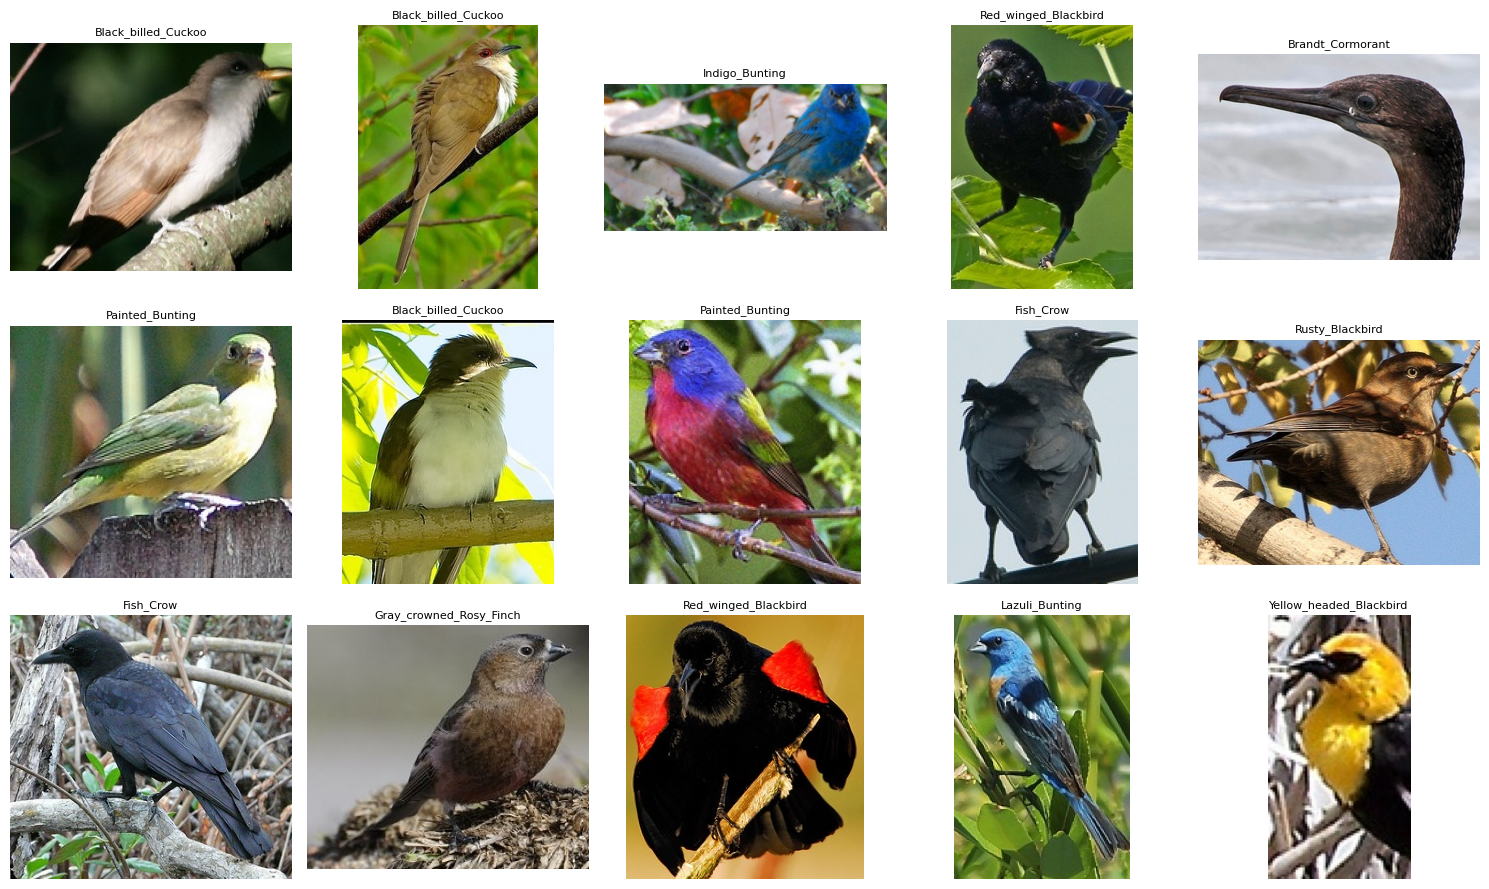

In [20]:
# Show a small grid of raw images
def show_image_grid(paths, labels, idx_to_class, rows=3, cols=5, seed=42):
    rng = np.random.default_rng(seed)
    total = rows * cols
    chosen = rng.choice(len(paths), size=min(total, len(paths)), replace=False)

    plt.figure(figsize=(cols * 3, rows * 3))
    for i, idx in enumerate(chosen):
        p = paths[idx]
        img = read_image_bgr(p)[:, :, ::-1]  # BGR -> RGB
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(idx_to_class[int(labels[idx])], fontsize=8)
        plt.axis('off')
    plt.tight_layout()

show_image_grid(train_paths, y_train, idx_to_class)


Now we check the HOG visualizations (edge/texture emphasis) for some samples:


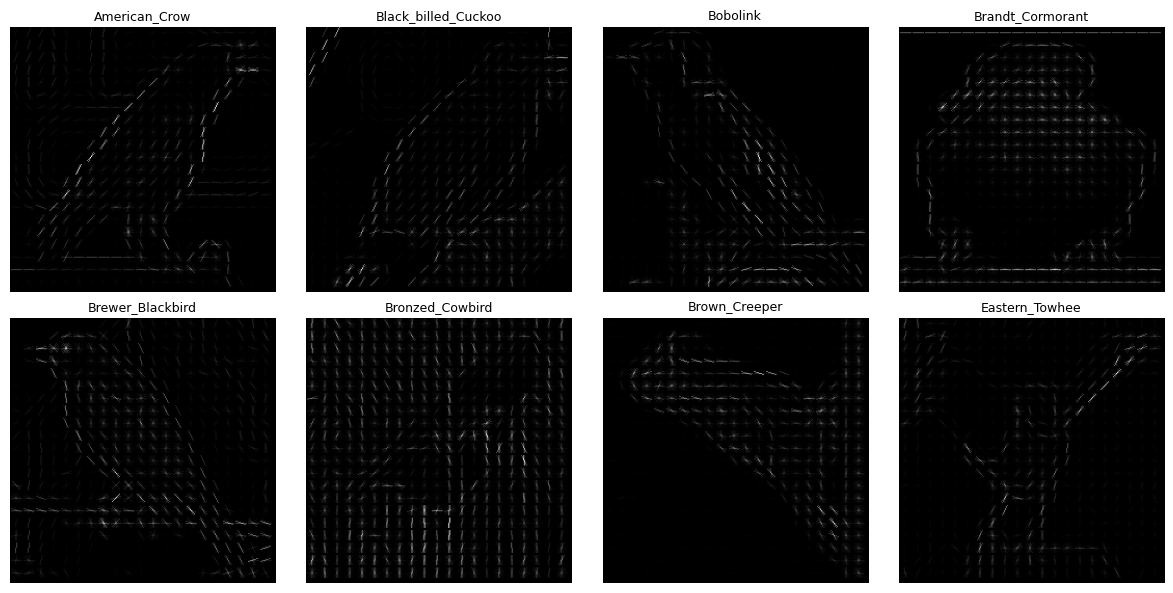

In [34]:
# HOG visualization grid (2 rows, classes laid out horizontally)
cfg = HogConfig(
    img_size=256,
    orientations=9,
    pixels_per_cell=12,
    cells_per_block=2,
    use_color_hist=True,
    color_hist_bins=32,
)

def show_hog_grid(paths, labels, idx_to_class, per_class=1, max_classes=8, seed=42):
    if not HOG_VIZ_OK:
        print("skimage not available; skipping HOG visualizations")
        return

    rng = np.random.default_rng(seed)
    classes = np.unique(labels)[:max_classes]
    n = len(classes)

    rows = 2
    cols = int(np.ceil(n / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_2d(axes)

    for i, cls in enumerate(classes):
        r = i // cols
        c = i % cols
        ax = axes[r, c]
        ax.axis("off")

        idx = np.where(labels == cls)[0]
        if len(idx) == 0:
            continue

        chosen = rng.choice(idx, size=1, replace=False)
        p = paths[chosen[0]]

        img = read_image_bgr(p)
        gray = preprocess_to_gray(img, cfg.img_size)

        _, hog_img = skimage_hog(
            gray,
            orientations=cfg.orientations,
            pixels_per_cell=(cfg.pixels_per_cell, cfg.pixels_per_cell),
            cells_per_block=(cfg.cells_per_block, cfg.cells_per_block),
            block_norm=cfg.block_norm,
            visualize=True,
            feature_vector=True,
        )

        ax.imshow(hog_img, cmap="gray")
        ax.set_title(idx_to_class[int(cls)], fontsize=9)

    # Turn off unused subplots
    for j in range(i + 1, rows * cols):
        r = j // cols
        c = j % cols
        axes[r, c].axis("off")

    plt.tight_layout()


show_hog_grid(train_paths, y_train, idx_to_class, per_class=1, max_classes=8)


Loading paths:

In [22]:
# Feature extraction (with optional caching)
cache_dir = out_dir / 'hog_cache'
cache_dir.mkdir(parents=True, exist_ok=True)

train_cache = cache_dir / 'train_hog.npz'
val_cache = cache_dir / 'val_hog.npz'

X_train = extract_features(train_paths, cfg, cache_npz=train_cache)
print('X_train:', X_train.shape)

if val_paths:
    X_val = extract_features(val_paths, cfg, cache_npz=val_cache)
    print('X_val:', X_val.shape)


X_train: (1082, 8100)
X_val: (103, 8100)


Training log regression model and printing val accuracy and cv 5-fold accuracy:

In [28]:
# Train Logistic Regression
model = build_model(C=12, max_iter=3000, n_jobs=4)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f'Train accuracy: {train_acc:.4f}')

if val_paths:
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f'Val accuracy: {val_acc:.4f}')
    print(classification_report(y_val, val_pred, target_names=[idx_to_class[i] for i in range(len(idx_to_class))]))

# 5-fold CV accuracy on training set
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accs = []
for tr_idx, te_idx in skf.split(X_train, y_train):
    cv_model = build_model(C=8.0, max_iter=3000, n_jobs=4)
    cv_model.fit(X_train[tr_idx], y_train[tr_idx])
    cv_pred = cv_model.predict(X_train[te_idx])
    cv_accs.append(accuracy_score(y_train[te_idx], cv_pred))

print(f'5-fold CV accuracy (train): {np.mean(cv_accs):.4f} with {np.std(cv_accs):.4f}')


c:\Users\stef4\Desktop\Machine Learning\image-classification-birds\.birds_ml_venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train accuracy: 1.0000
Val accuracy: 0.2039
                         precision    recall  f1-score   support

          American_Crow       0.25      0.14      0.18         7
    Black_billed_Cuckoo       0.14      0.20      0.17         5
               Bobolink       0.25      0.50      0.33         2
       Brandt_Cormorant       0.50      0.33      0.40         6
       Brewer_Blackbird       0.00      0.00      0.00         4
        Bronzed_Cowbird       0.00      0.00      0.00         8
          Brown_Creeper       0.71      0.71      0.71         7
         Eastern_Towhee       0.00      0.00      0.00         6
              Fish_Crow       0.25      0.17      0.20         6
           Gray_Catbird       0.00      0.00      0.00         5
Gray_crowned_Rosy_Finch       0.50      0.50      0.50         8
      Groove_billed_Ani       0.25      1.00      0.40         2
         Indigo_Bunting       0.14      0.33      0.20         3
         Lazuli_Bunting       0.00      0.00 

c:\Users\stef4\Desktop\Machine Learning\image-classification-birds\.birds_ml_venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\stef4\Desktop\Machine Learning\image-classification-birds\.birds_ml_venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\stef4\Desktop\Machine Learning\image-classification-birds\.birds_ml_venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to av

5-fold CV accuracy (train): 0.2209 with 0.0210


Next the confusion matrix

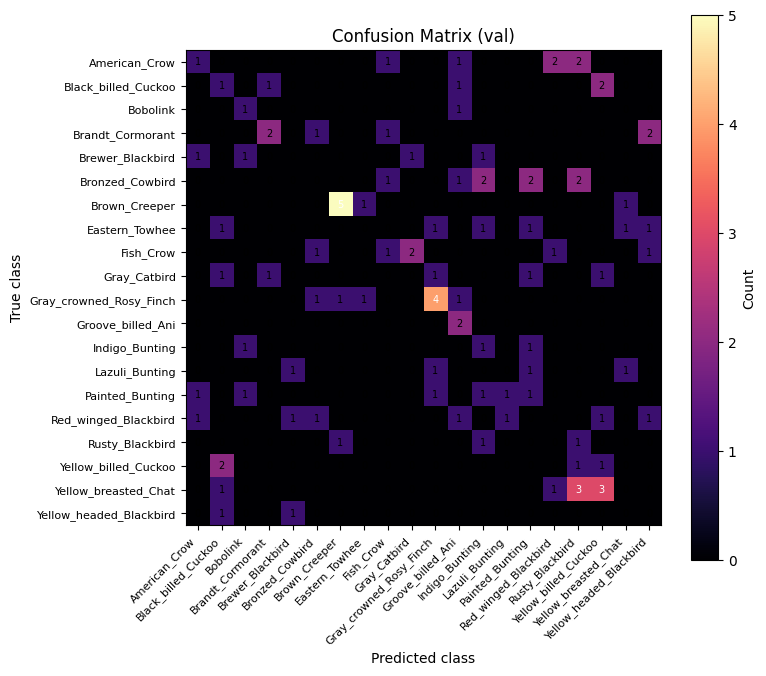

In [29]:
# Confusion matrix (val) with class names
if val_paths:
    cm = confusion_matrix(y_val, val_pred)
    labels = [idx_to_class[i] for i in range(len(idx_to_class))]

    plt.figure(figsize=(8, 7))
    im = plt.imshow(cm, cmap='magma')
    plt.title('Confusion Matrix (val)')
    plt.colorbar(im, label='Count')

    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha='right', fontsize=8)
    plt.yticks(ticks=np.arange(len(labels)), labels=labels, fontsize=8)
    plt.xlabel('Predicted class')
    plt.ylabel('True class')

    # Annotate counts
    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f'{cm[i, j]}',
                     ha='center', va='center',
                     color='white' if cm[i, j] > thresh else 'black',
                     fontsize=7)

    plt.tight_layout()


Lastly the t-SNE visualization of HOG feature space:

C:\Users\stef4\AppData\Local\Temp\ipykernel_18112\1301679946.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(classes))


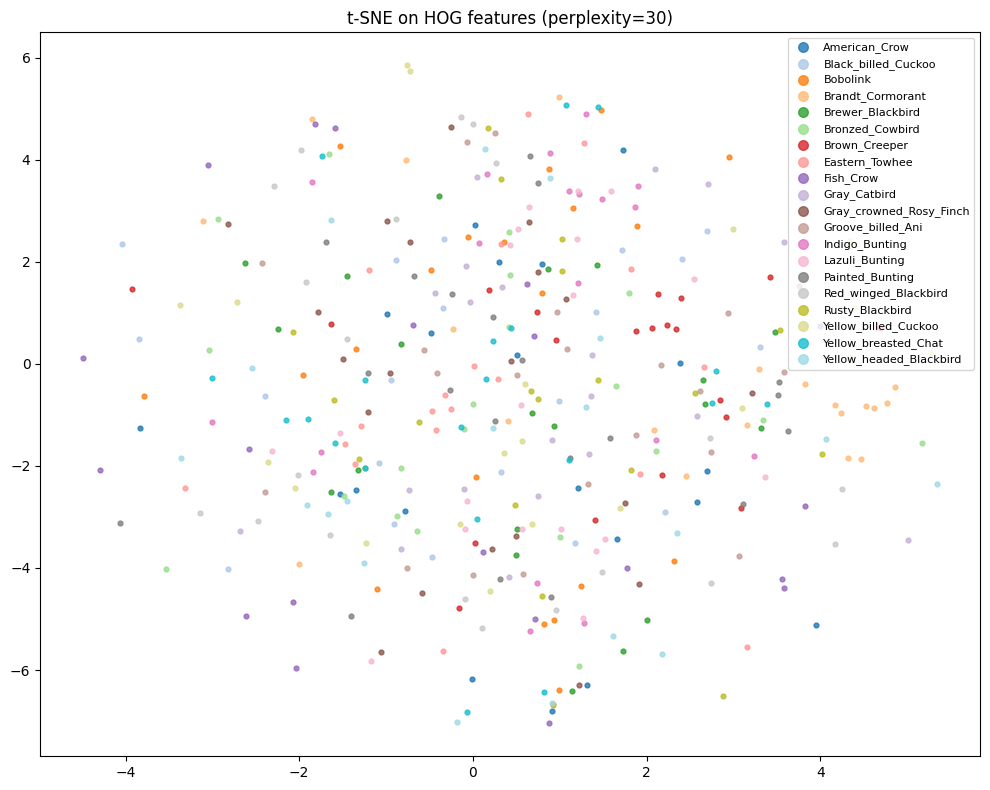

In [30]:
# t-SNE on HOG features (subset for speed)
def stratified_sample(paths, labels, per_class=30, seed=42):
    rng = np.random.default_rng(seed)
    out_paths = []
    out_labels = []
    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]
        take = min(per_class, len(idx))
        chosen = rng.choice(idx, size=take, replace=False)
        for i in chosen:
            out_paths.append(paths[i])
            out_labels.append(int(labels[i]))
    return out_paths, np.asarray(out_labels, dtype=np.int64)

tsne_paths, tsne_labels = stratified_sample(train_paths, y_train, per_class=20)
X_tsne = extract_features(tsne_paths, cfg, cache_npz=None)

perplexity = min(30, max(5, len(X_tsne) // 10))
tsne = TSNE(n_components=2, perplexity=perplexity, init='pca', learning_rate='auto', random_state=42)
Z = tsne.fit_transform(X_tsne)

plt.figure(figsize=(10, 8))
classes = np.unique(tsne_labels)
cmap = plt.cm.get_cmap('tab20', len(classes))
for i, cls in enumerate(classes):
    idx = tsne_labels == cls
    plt.scatter(Z[idx, 0], Z[idx, 1], s=12, color=cmap(i), label=idx_to_class[cls], alpha=0.8)

if len(classes) <= 20:
    plt.legend(markerscale=2, fontsize=8, loc='best')
plt.title(f't-SNE on HOG features (perplexity={perplexity})')
plt.tight_layout()
